In [1]:
import pandas as pd # for reading the data
import numpy as np # for data manipulation
import scipy.optimize as opt # for optimization
import matplotlib.pyplot as plt

### Exercise 01 - Regression
**Jenny Laberg Nilsson**  
**BERN02 - 2026/09**

**Project:** Fit a local regression over each point X0 =[10,18,25]  
**X0**: This is the targeted test point  
**k:** The number of points in the training data that are closest to the test point (X0)   
**Quantity of interest:** Mortality rate as a function of income (MORT vs. POOR)  
**Predictors:** POOR - (% of families with income < $3000)  
**Response:** MORT - (Total age-adjusted mortality rate per 100,000)   
**Model:** Local regression    

In [2]:
# Load pollution data
pollution_df = pd.read_csv("../data/pollution_cleaneddata.csv", encoding='utf-8')
# print the first 5 rows of the dataframe for a quick check of the data
pollution_df.head()

,PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO@,HUMID,MORT
0,36.0,27.0,71.0,8.1,3.34,11.4,81.5,3243.0,8.8,42.6,11.7,21.0,15.0,59.0,59.0,921.870
1,35.0,23.0,72.0,11.1,3.14,11.0,78.8,4281.0,3.5,50.7,14.4,8.0,10.0,39.0,57.0,997.875
2,44.0,29.0,74.0,10.4,3.21,9.8,81.6,4260.0,0.8,39.4,12.4,6.0,6.0,33.0,54.0,962.354
3,47.0,45.0,79.0,6.5,3.41,11.1,77.5,3125.0,27.1,50.2,20.6,18.0,8.0,24.0,56.0,982.291
4,43.0,35.0,77.0,7.6,3.44,9.6,84.6,6441.0,24.4,43.7,14.3,43.0,38.0,206.0,55.0,1071.289


In [3]:
def local_x(x, y, x0, k):
    """
    Find the closest points to x0 by calculating the squared distance between each point in x and x0.
    k is the number of x closest points to x0 to return.
    The function returns a list of tuples containing the squared distance and the x and y coordinates for the k closest points.
    """
    # make a empty list for storing the squared distances between each point in x and x0 and the coordinates of the points in x and y
    squared_distances_list = []
    # loop through each point in x and calculate the squared distance between the point and x0
    for i in range(len(x)):
        squared_distance = float((x[i] - x0) ** 2)
        y_value = float(y[i])
        x_value = float(x[i])
        squared_distances_list.append((squared_distance, x_value, y_value))
    # sort list by the squared distances so that the closest points are at the beginning of the list
    squared_distances_list.sort()
    # return the k closest points
    return squared_distances_list[:k]


In [4]:
def optimize_sum_of_squares(beta, x_closest, y_closest, weights):
    """
    Find the optimal beta parameters for the weighted linear regression model by minimizing the sum of squares.
    """
    beta_0 = beta[0]
    beta_1 = beta[1]

    # calculate the sum of squares
    eq = weights * (y_closest - (beta_0 + beta_1 * x_closest)) ** 2
    return(eq.sum())

In [5]:
def weight_function(x_closest, x0):
    """
    Calculate the weights for each point in x based on the distance from x0 using a Gaussian kernel (function found online).
    """
    # compute the physical distance on the x-axis for each local point
    distances = np.abs(x_closest - x0)
    
    # compute the distance to the furthest of the k neighbors
    d_max = np.max(distances)
    
    if d_max == 0:
        return np.ones_like(distances)
    
    # Gaussian kernel normalized by d_max
    weights = np.exp(-0.5 * (distances / d_max) ** 2)
    return weights

In [ ]:
def local_regression(x, y, x0, k):
    """
    Perform local regression on the data using the k closest points to x0. 
    Returns:
      - y_0: predicted expected value at x0
      - rse: standard deviation of residuals (Residual Standard Error)
      - se_y_hat: standard error of the expected value E[Y|x0]
    """
    # Allows x0 to be a list or array and returns a list of predicted values for each value in x0
    if isinstance(x0, (list, np.ndarray)):
        return [local_regression(x, y, val, k) for val in x0]
        
    # get the closets x and their coordinates of the k closest points to x0 by calling the local_x function
    closest_points = local_x(x, y, x0, k)

    # extract only the coordinates and make it into an array for easier calculations
    x_closest = np.array([point[1] for point in closest_points])
    y_closest = np.array([point[2] for point in closest_points])

    # I also have to calculate the weights for each point in x_closest based on the distance from x0 by calling the weight_function
    weights = weight_function(x_closest, x0)

    # find the most optimal beta parametes (fit the model)
    beta = opt.minimize(optimize_sum_of_squares, [0, 0], args=(x_closest, y_closest, weights)).x
    beta_0 = beta[0]
    beta_1 = beta[1]

    # predict expected value (y_0) at x0 using the fitted model
    y_0 = beta_0 + beta_1 * x0

    # 1. Residuals
    residuals = y_closest - (beta_0 + beta_1 * x_closest)

    # 2. Weighted RSE
    weighted_sse = np.sum(weights * (residuals ** 2))
    rse = np.sqrt(weighted_sse / (k - 2))

    # 3. Weighted center of neighborhood
    w_sum = np.sum(weights)
    x_bar_w = np.sum(weights * x_closest) / w_sum
    ss_xw = np.sum(weights * ((x_closest - x_bar_w) ** 2))

    # 4. Weighted SE at x0
    se_y_hat = rse * np.sqrt((1 / w_sum) + (((x0 - x_bar_w) ** 2) / ss_xw))

    return float(y_0), float(rse), float(se_y_hat)

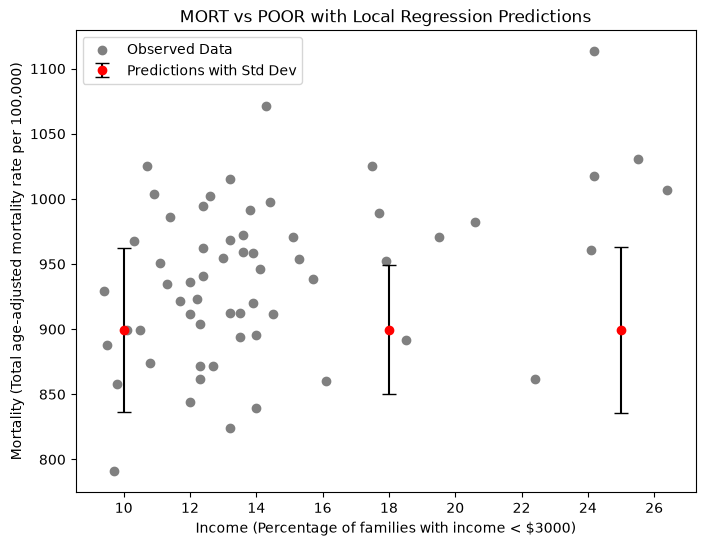

   x0  Predicted y  Standard Error of the prediction
0  10   899.516565                         20.952345
1  18   899.516565                         16.546851
2  25   899.516565                         27.601611


In [ ]:
# Output the predicted value of y at x0 and the standard deviation of the residuals for each x0 in X0
# Also plot the data with the predicted values and the standard deviation of the residuals as error bars

# choosen x0 values to predict and set k value to 5
X0 =[10,18,25]
k_val = 5

# call the local_regression function 
results = local_regression(pollution_df['POOR'], pollution_df['MORT'], X0, k_val)

# get the predicted values, standard deviations and standard errors for predictions
predictions = [results[0] for result in results]
std_devs = [result[1] for result in results]
SE_y_hats = [result[2] for result in results]


# Plot the data with the predicted values and the standard deviation of the residuals as error bars
plt.figure(figsize=(8,6))
plt.title("MORT vs POOR with Local Regression Predictions")
plt.scatter(pollution_df['POOR'], pollution_df['MORT'], label='Observed Data', color='gray')
# set the x axis to be only whole numbers
plt.xticks(np.arange(0, 31, 2))
plt.errorbar(X0, [pred[0] for pred in predictions], yerr=std_devs, fmt='o', color='red', ecolor='black', capsize=5, label='Predictions with Std Dev')
plt.xlabel("Income (Percentage of families with income < $3000)")
plt.ylabel("Mortality (Total age-adjusted mortality rate per 100,000)")
plt.legend()
plt.show()

# Print the predicted values and standard deviations for each x0 in X0 as a table
results_df = pd.DataFrame({'x0': X0, 'Predicted y': [pred[0] for pred in predictions], 'Standard Error of the prediction': SE_y_hats})
print(results_df)


In [8]:
# Look at the effect of changing k on the predicted values and standard deviations for each x0 in X0
# How to choose k? 
# The choice of k is a trade-off between bias and variance. 
# A smaller k will result in a model that is more flexible and can capture more local patterns in the data, but it may also be more sensitive to noise and outliers. 
# A larger k will result in a smoother model that is less sensitive to noise, but it may also miss some local patterns in the data. 
# In practice, k is often chosen using cross-validation or other model selection techniques.
print("k = 4: ", local_regression(pollution_df['POOR'], pollution_df['MORT'], [10, 18, 25], k=4))
print("k = 25:", local_regression(pollution_df['POOR'], pollution_df['MORT'], [10, 18, 25], k=25))

k = 4:  [(885.3855636085027, 22.910174702956766, 11.517855423263867), (950.0828530117378, 11.472264697502775, 5.937461066554352), (1033.1127139490932, 76.85363156881033, 50.779676279653245)]
k = 25: [(905.5392697096256, 55.98427926943431, 17.937186669312485), (945.6411077569943, 60.20149461936846, 16.718748406729716), (1004.220724515703, 61.81147165790596, 24.465461466796075)]
